# Binary Logistic Regression Demonstration In Python
#### Marketing Campaing Response Model
   

## Background: 
The large skin-clinic in the city of “XXX” offers variety of products and services to customers. The marketing campaign was launched for introducing a new product.

The data shows response to the marketing campaign alongwith demographic and transaction data of customers.

The objective is to develop a predictive model which can be implemented for the next campaign

## Dataset Description :

| Column Name     | Description                                                                                  |
|-----------------|----------------------------------------------------------------------------------------------|
| Custid          | Unique Customer Identification Code                                                          |
| Age             | Age Group (1: <32 years, 2: 32–48 years, 3: >48 years)                                      |
| Gender          | Gender of Customer (1: Female, 2: Male)                                                     |
| MS              | Marital Status (1: Not Married, 2: Married)                                                 |
| Response        | Customer Campaign Response (1: Responded, 0: Not Responded)                                 |
| Pre_Month       | Purchase Status in Previous Month (1: Purchased, 2: No Purchase)                            |
| N_Products      | Number of Unique Products Purchased in One Year                                             |
| N_Service       | Number of Unique Services Purchased in One Year                                             |
| BillAmt_1       | Bill Amount (USD) for Purchase Transaction 1                                                |
| BillAmt_2       | Bill Amount (USD) for Purchase Transaction 2                                                |
| BillAmt_3       | Bill Amount (USD) for Purchase Transaction 3                                                |


### 1. Import Libraries

In [60]:
import pandas as pd  
import numpy as np
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

### 2. Import Data

In [61]:
purchase_data1 = pd.read_csv('Purchase Data 1.csv')
purchase_data2 = pd.read_csv('Purchase Data 2.csv')
response_data = pd.read_csv('Response Data.csv')

#Merging above 3 datasets
masterdata=pd.merge(response_data,purchase_data1,how='left',on = 'Custid')
masterdata=pd.merge(masterdata,purchase_data2,how='left',on = 'Custid')
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [62]:
masterdata.dtypes

Custid          int64
Age             int64
Gender          int64
MS              int64
Response        int64
Pre_Month       int64
N_Products      int64
N_Service       int64
BillAmt_1     float64
BillAmt_2     float64
BillAmt_3     float64
dtype: object

### 3. Variable Type Conversion: Integer → Category

In [63]:
masterdata['Age'] = masterdata['Age'].astype('category')
masterdata['Gender'] = masterdata['Gender'].astype('category')
masterdata['MS'] = masterdata['MS'].astype('category')
masterdata['Pre_Month'] = masterdata['Pre_Month'].astype('category')

### 4. Perform Feature Engineering (Recoding Variables)

As part of feature engineering, we will recode a continuous numerical variable into three meaningful buckets (Low, Medium, High) to simplify the distribution and make the model interpret the pattern more effectively

In [64]:
#Recoding Numerical variables to Categorical
masterdata['BillAmt_1_Bucket'] = pd.qcut(
    masterdata['BillAmt_1'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

masterdata['BillAmt_2_Bucket'] = pd.qcut(
    masterdata['BillAmt_2'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

masterdata['BillAmt_3_Bucket'] = pd.qcut(
    masterdata['BillAmt_3'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
masterdata.head()


,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3,BillAmt_1_Bucket,BillAmt_2_Bucket,BillAmt_3_Bucket
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88,Medium,High,High
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13,High,Medium,High
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65,Low,High,Medium
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34,Low,Medium,Low
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07,High,Medium,High


### 5. Estimating Campaign Response Rate : Overall and by Segments


### a. Overall Campaign Response Rate

In [65]:
# Overall response rate
overall_response_rate = masterdata['Response'].mean() * 100
print(f"Overall Campaign Response Rate: {overall_response_rate:.2f}%")

Overall Campaign Response Rate: 13.23%


### b. Segmented Campaign Response Rate

In [66]:
# List of segmentation variables
segments = ['Age', 'Gender', 'MS', 'Pre_Month']

response_summary = {}

for col in segments:
    response_summary[col] = (
        masterdata.groupby(col)['Response']
        .mean()
        .mul(100)   # convert to %
        .round(2)
    )

response_summary

for key, value in response_summary.items():
    print(f"\nResponse Rate by {key}:")
    print(value)


Response Rate by Age:
Age
1    13.73
2    12.46
3    13.52
Name: Response, dtype: float64

Response Rate by Gender:
Gender
1    12.79
2    13.68
Name: Response, dtype: float64

Response Rate by MS:
MS
1    13.55
2    12.91
Name: Response, dtype: float64

Response Rate by Pre_Month:
Pre_Month
1    13.39
2    13.08
Name: Response, dtype: float64


### 6. Assessing Numerical Variables by Campaign Response Indicator


In [67]:
numeric_vars = ['N_Products','N_Service', 'BillAmt_1', 'BillAmt_2', 'BillAmt_3']

numeric_eda = masterdata.groupby('Response')[numeric_vars].describe().transpose()
numeric_eda

Response                    0           1
N_Products count  6065.000000  925.000000
           mean     23.560099   27.699459
           std       6.800788    4.307505
           min       1.000000    3.000000
           25%      19.000000   25.000000
           50%      25.000000   29.000000
           75%      29.000000   31.000000
           max      33.000000   33.000000
N_Service  count  6065.000000  925.000000
           mean     26.940643   29.100541
           std       6.983356    5.382918
           min       1.000000    6.000000
           25%      23.000000   27.000000
           50%      28.000000   30.000000
           75%      33.000000   33.000000
           max      36.000000   36.000000
BillAmt_1  count  6065.000000  925.000000
           mean     12.342041   15.473643
           std       6.940059    6.677068
           min       0.690000    0.910000
           25%       7.310000   10.370000
           50%      10.770000   15.210000
           75%      15.940000   19.860000
           max      45.330000   33.590000
BillAmt_2  count  6065.000000  925.000000
           mean      2.987598    3.365081
           std       2.268582    2.348871
           min       0.050000    0.270000
           25%       1.650000    1.920000
           50%       2.590000    2.990000
           75%       3.620000    4.070000
           max      22.270000   22.490000
BillAmt_3  count  6065.000000  925.000000
           mean      4.035880    4.194768
           std       3.320684    3.456211
           min       0.000000    0.000000
           25%       2.060000    2.160000
           50%       3.000000    3.200000
           75%       4.850000    5.230000
           max      28.640000   28.740000

### 7.  Model A: Logistic Regression with Bill Amounts as Numeric Features  | Treats spending as continuous |



### a. Check for Multicollinearity problem

In [68]:

y1, X1 = dmatrices('Response~Age+Gender+MS+Pre_Month+N_Products+N_Service+BillAmt_1+BillAmt_2+BillAmt_3', data=masterdata, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept         41.887248
Age[T.2]           1.320898
Age[T.3]           1.319500
Gender[T.2]        1.001581
MS[T.2]            1.001546
Pre_Month[T.2]     1.001391
N_Products         1.507631
N_Service          1.138544
BillAmt_1          1.793005
BillAmt_2          1.688835
BillAmt_3          2.111681
dtype: float64

#### Since all VIF'S < 5, no multicollinearity problem detected

#### Inference :
It is observed that no variable has high vif. Hence, the problem of multicollinearity does not exist

### b. Create dummies (for categorical variables)

In [69]:
categorical_vars = ['Age', 'Gender', 'MS', 'Pre_Month','BillAmt_1_Bucket',
       'BillAmt_2_Bucket', 'BillAmt_3_Bucket']
dummies = pd.get_dummies(masterdata[categorical_vars], drop_first=True)

# Append (concatenate) dummy columns to masterdata
masterdata = pd.concat([masterdata, dummies], axis=1)

### c.  Split Data Into Train & Test

In [70]:
X_temp = masterdata.drop(columns=['Response','Custid'])
y = masterdata['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y, test_size=0.3, random_state=42, stratify=y
)

# Display shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("\nTrain Response Distribution:\n", y_train.value_counts(normalize=True)*100)
print("\nTest Response Distribution:\n", y_test.value_counts(normalize=True)*100)

Training Data Shape: (4893, 23)
Testing Data Shape: (2097, 23)

Train Response Distribution:
 Response
0    86.756591
1    13.243409
Name: proportion, dtype: float64

Test Response Distribution:
 Response
0    86.790653
1    13.209347
Name: proportion, dtype: float64


In [71]:
model_A_vars = ['N_Products', 'N_Service', 'BillAmt_1',
       'BillAmt_2', 'BillAmt_3', 'Age_2', 'Age_3', 'Gender_2', 'MS_2',
       'Pre_Month_2']

In [72]:
X_train_A = X_train[model_A_vars]
X_test_A  = X_test[model_A_vars]

### d. Build Model

In [73]:
logreg = LogisticRegression(max_iter=200)

logreg.fit(X_train_A,y_train)

LogisticRegression(max_iter=200)

#### Display Model Coefficients

In [74]:
coeff_df = pd.DataFrame({
    'Feature': X_train_A.columns,
    'Coefficient': logreg.coef_[0]
})

coeff_df

,Feature,Coefficient
0,N_Products,0.149219
1,N_Service,0.042596
2,BillAmt_1,0.032358
3,BillAmt_2,0.203652
4,BillAmt_3,0.002609
5,Age_2,-0.136290
6,Age_3,0.029717
7,Gender_2,0.009916
8,MS_2,-0.036924
9,Pre_Month_2,0.054174


### 8. Evaluate Model Performance : ROC Curve

### a. ROC Curve For Train & Test Data

In [75]:
y_train_pred_prob = logreg.predict_proba(X_train_A)[:,1]
y_test_pred_prob = logreg.predict_proba(X_test_A)[:,1]
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train, y_train_pred_prob)
test_auc = roc_auc_score(y_test, y_test_pred_prob)

print("Train AUC Score:", round(train_auc,4))
print("Test AUC Score:", round(test_auc,4))


Train AUC Score: 0.7541
Test AUC Score: 0.7304


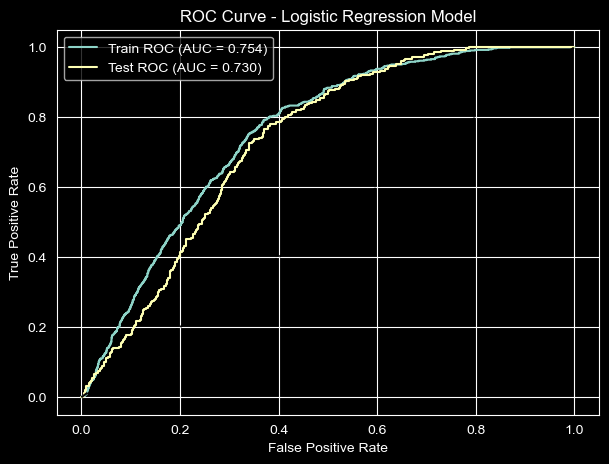

In [76]:
# ROC curve values
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.3f})')

# Reference diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()


### b. Find Optimum Threshold for classification by maximizing sensitivity + specificity


In [77]:
fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_prob)
i = np.arange(len(tpr))

# Build ROC dataframe
roc = pd.DataFrame({
    'fpr'        : pd.Series(fpr, index=i),
    'tpr'        : pd.Series(tpr, index=i),
    '1-fpr'      : pd.Series(1-fpr, index=i),
    'tf'         : pd.Series(tpr - (1-fpr), index=i),  # Youden's J statistic
    'thresholds' : pd.Series(thresholds, index=i)
})

# Find optimal threshold (maximizing sensitivity-specificity difference)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc.iloc[optimal_idx]['thresholds']

print("Optimal Threshold:", round(optimal_threshold,4))


Optimal Threshold: 0.13


### c. Apply Threshold — Train Confusion Matrix & Classification Report

In [78]:
# Predict based on threshold
y_train_pred_opt = (y_train_pred_prob >= optimal_threshold).astype(int)

print("\nTRAIN CONFUSION MATRIX:")
print(confusion_matrix(y_train, y_train_pred_opt))

print("\nTRAIN CLASSIFICATION REPORT:")
print(classification_report(y_train, y_train_pred_opt))



TRAIN CONFUSION MATRIX:
[[2676 1569]
 [ 135  513]]

TRAIN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      4245
           1       0.25      0.79      0.38       648

    accuracy                           0.65      4893
   macro avg       0.60      0.71      0.57      4893
weighted avg       0.86      0.65      0.71      4893



### d.  Apply Threshold — Test Confusion Matrix  & Classification Report

In [79]:
y_test_pred_opt = (y_test_pred_prob >= optimal_threshold).astype(int)

print("\nTEST CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_test_pred_opt))

print("\nTEST CLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred_opt))



TEST CONFUSION MATRIX:
[[1149  671]
 [  69  208]]

TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.94      0.63      0.76      1820
           1       0.24      0.75      0.36       277

    accuracy                           0.65      2097
   macro avg       0.59      0.69      0.56      2097
weighted avg       0.85      0.65      0.70      2097



### 9. Model Validation : K-Fold Cross Validation Method

In [80]:
X = masterdata[model_A_vars]
y = masterdata['Response']

predicted_prob = cross_val_predict(logreg, X, y, cv=4, method='predict_proba') 
threshold=optimal_threshold
predicted = predicted_prob[:,1]
predicted_class1=np.zeros(predicted.shape)
predicted_class1[predicted>threshold]=1

print(classification_report(y,predicted_class1))

              precision    recall  f1-score   support

           0       0.95      0.63      0.75      6065
           1       0.24      0.77      0.37       925

    accuracy                           0.65      6990
   macro avg       0.59      0.70      0.56      6990
weighted avg       0.85      0.65      0.70      6990



###  10. Model B: Logistic Regression with Bill Amounts Converted to Buckets | Treats spending behavior as categories |



### a. Check for  Multicollinearity problem

In [81]:
y1, X1 = dmatrices('Response~Age+Gender+MS+Pre_Month+N_Products+N_Service+BillAmt_1_Bucket+BillAmt_2_Bucket+BillAmt_3_Bucket', data=masterdata, return_type="dataframe")

vif = pd.Series([variance_inflation_factor(X1.values, i)for i in range(X1.shape[1])],index=X1.columns)
vif

Intercept                     41.153883
Age[T.2]                       1.321776
Age[T.3]                       1.319494
Gender[T.2]                    1.001851
MS[T.2]                        1.001867
Pre_Month[T.2]                 1.002279
BillAmt_1_Bucket[T.Medium]     1.592476
BillAmt_1_Bucket[T.High]       2.416550
BillAmt_2_Bucket[T.Medium]     1.357093
BillAmt_2_Bucket[T.High]       1.803685
BillAmt_3_Bucket[T.Medium]     1.552139
BillAmt_3_Bucket[T.High]       2.468173
N_Products                     1.401665
N_Service                      1.145048
dtype: float64

#### Since all VIF'S < 5, no multicollinearity problem detected

### b. Train & Test Data

In [82]:
model_B_vars = ['N_Products', 'N_Service','Age_2', 'Age_3', 'Gender_2', 'MS_2',
       'Pre_Month_2', 'BillAmt_1_Bucket_Medium', 'BillAmt_1_Bucket_High',
       'BillAmt_2_Bucket_Medium', 'BillAmt_2_Bucket_High',
       'BillAmt_3_Bucket_Medium', 'BillAmt_3_Bucket_High']

In [83]:
X_train_B = X_train[model_B_vars]
X_test_B  = X_test[model_B_vars]
# Display shapes
print("Training Data Shape:", X_train_B.shape)
print("Testing Data Shape:", X_test_B.shape)
print("\nTrain Response Distribution:\n", y_train.value_counts(normalize=True)*100)
print("\nTest Response Distribution:\n", y_test.value_counts(normalize=True)*100)


Training Data Shape: (4893, 13)
Testing Data Shape: (2097, 13)

Train Response Distribution:
 Response
0    86.756591
1    13.243409
Name: proportion, dtype: float64

Test Response Distribution:
 Response
0    86.790653
1    13.209347
Name: proportion, dtype: float64


### c. Build Model

In [84]:
logreg_b = LogisticRegression(max_iter=500)

logreg_b.fit(X_train_B,y_train)

LogisticRegression(max_iter=500)

### Display Model Coefficients

In [85]:
coeff_df = pd.DataFrame({
    'Feature': X_train_B.columns,
    'Coefficient': logreg_b.coef_[0]
})

coeff_df

,Feature,Coefficient
0,N_Products,0.134427
1,N_Service,0.042456
2,Age_2,-0.129465
3,Age_3,0.028809
4,Gender_2,0.009130
5,MS_2,-0.029105
6,Pre_Month_2,0.036591
7,BillAmt_1_Bucket_Medium,0.244538
8,BillAmt_1_Bucket_High,0.733353
9,BillAmt_2_Bucket_Medium,0.070549


### 11. Evaluate Model Performance : ROC Curve

In [86]:
y_train_pred_prob_b = logreg_b.predict_proba(X_train_B)[:,1]
y_test_pred_prob_b = logreg_b.predict_proba(X_test_B)[:,1]
from sklearn.metrics import roc_auc_score

train_auc_b = roc_auc_score(y_train, y_train_pred_prob_b)
test_auc_b = roc_auc_score(y_test, y_test_pred_prob_b)

print("Train AUC Score:", round(train_auc_b,4))
print("Test AUC Score:", round(test_auc_b,4))


Train AUC Score: 0.7516
Test AUC Score: 0.7445


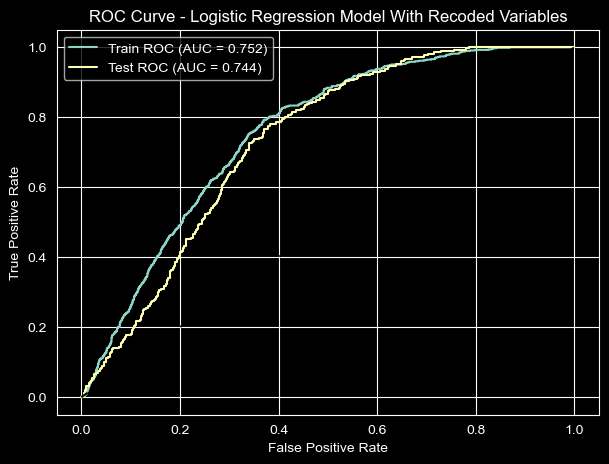

In [87]:
# ROC curve values
fpr_train_b, tpr_train_b, _ = roc_curve(y_train, y_train_pred_prob_b)
fpr_test_b, tpr_test_b, _ = roc_curve(y_test, y_test_pred_prob_b)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc_b:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc_b:.3f})')

# Reference diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Model With Recoded Variables")
plt.legend()
plt.grid(True)
plt.show()


### Performance Comparison                                           


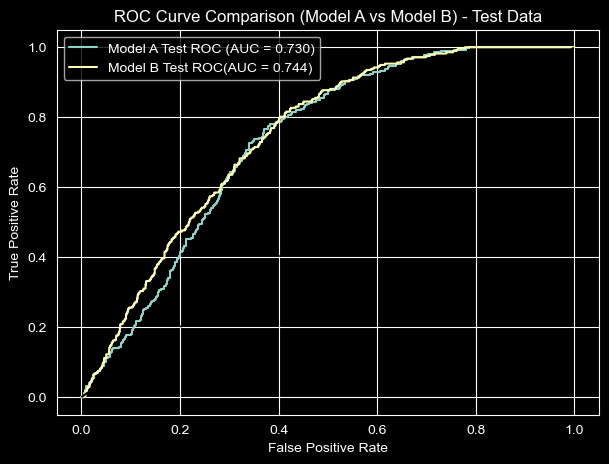

In [88]:
# ---------- Plot Combined ROC ----------
plt.figure(figsize=(7,5))

#plt.plot(fpr_test, tpr_test, label=f'Model A (AUC = {test_auc:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Model A Test ROC (AUC = {test_auc:.3f})')

plt.plot(fpr_test_b, tpr_test_b, label=f'Model B Test ROC(AUC = {test_auc_b:.3f})')

# Reference line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Model A vs Model B) - Test Data")
plt.legend()
plt.grid(True)
plt.show()